# 📊 Analisis Sentimen TikTok Tokopedia Seller Center Reviews

**Tujuan:** Melakukan analisis sentimen end-to-end terhadap ulasan pengguna TikTok Seller Center.

**Alur Analisis:**
1. Exploratory Data Analysis (EDA)
2. Preprocessing Teks
3. Splitting Data
4. Vectorization (TF-IDF)
5. Modelling (Naive Bayes, SVM, Random Forest)
6. Evaluasi Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Sastrawi (stemming Bahasa Indonesia)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)

# WordCloud
from wordcloud import WordCloud

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


## 1. Load Data & EDA (Exploratory Data Analysis)

In [2]:
# Load dataset
df = pd.read_csv('Tiktok Tokopedia Seller Center Reviews.csv')

print(f"📊 Jumlah data: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"\n📋 Kolom: {list(df.columns)}")
print(f"\n🔍 Tipe data:")
print(df.dtypes)
df.head(25)

📊 Jumlah data: 3145 baris, 2 kolom

📋 Kolom: ['content', 'sentiment']

🔍 Tipe data:
content      object
sentiment    object
dtype: object


,content,sentiment
0,tolong keuangan transfer rekening berbeda reke...,negative
1,sumpah ya aplikasi seller buruk tuh duitnya la...,negative
2,susah ribet,negative
3,capai bikin dekripsi tolak kacau,negative
4,pelanggaran upload barang,negative
5,saldo masuk beda aplikasi shope tokopedia oris...,negative
6,saldo dana berkurangdengan notif transaksi tik...,negative
7,hancur tiktok seller maunya,negative
8,approve pesanan masal tolong diperbaiki secepa...,negative
9,daftar gagal pas daftar ktp notif mencapai bat...,negative


In [3]:
# Cek missing values & duplikat
print("🔍 Missing Values:")
print(df.isnull().sum())
print(f"\n🔍 Jumlah duplikat: {df.duplicated().sum()}")

# Hapus duplikat
df = df.drop_duplicates().reset_index(drop=True)
print(f"✅ Jumlah data setelah hapus duplikat: {df.shape[0]}")

🔍 Missing Values:
content      0
sentiment    0
dtype: int64

🔍 Jumlah duplikat: 769
✅ Jumlah data setelah hapus duplikat: 2376


📊 Distribusi Sentimen:
sentiment
negative    1685
positive     691
Name: count, dtype: int64

Persentase:
sentiment
negative    70.917508
positive    29.082492
Name: proportion, dtype: float64


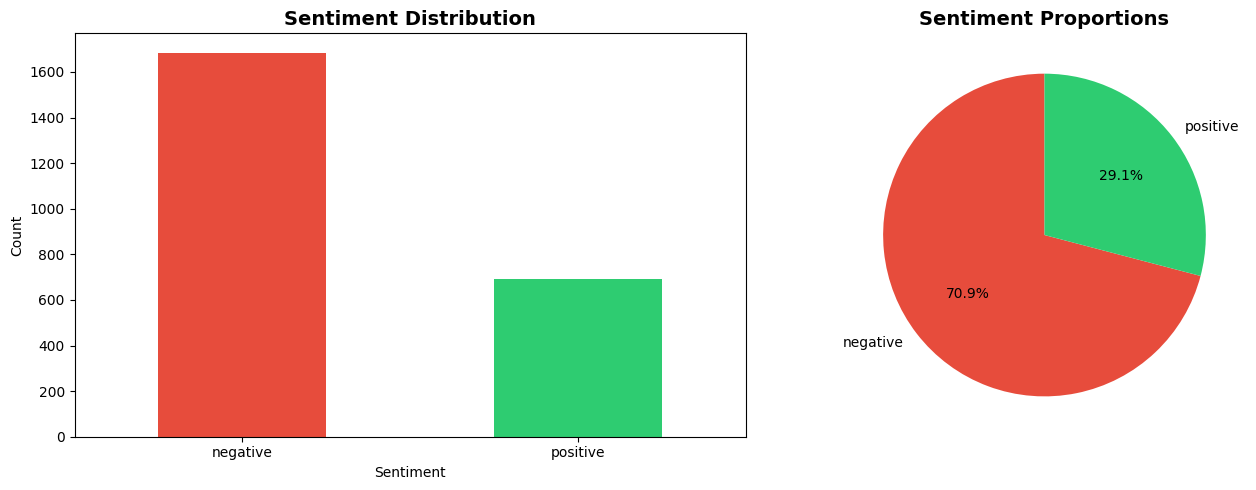

In [4]:
# Distribusi Sentimen
print("📊 Distribusi Sentimen:")
print(df['sentiment'].value_counts())
print(f"\nPersentase:")
print(df['sentiment'].value_counts(normalize=True) * 100)

# Visualisasi distribusi sentimen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = {'negative': '#e74c3c', 'positive': '#2ecc71'}
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0],
       color=[colors.get(x, '#3498db') for x in df['sentiment'].value_counts().index])
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['sentiment'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
       colors=[colors.get(x, '#3498db') for x in df['sentiment'].value_counts().index],
       startangle=90)
axes[1].set_title('Sentiment Proportions', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

📊 Statistik Panjang Teks:
          text_length                                            word_count  \
                count  mean   std  min   25%   50%    75%    max      count   
sentiment                                                                     
negative       1685.0  83.8  69.4  3.0  32.0  65.0  113.0  363.0     1685.0   
positive        691.0  27.3  27.2  2.0  13.0  20.0   33.0  281.0      691.0   

                                                 
           mean  std  min  25%  50%   75%   max  
sentiment                                        
negative   11.5  9.4  1.0  5.0  9.0  15.0  49.0  
positive    3.7  3.6  1.0  2.0  3.0   4.0  36.0  


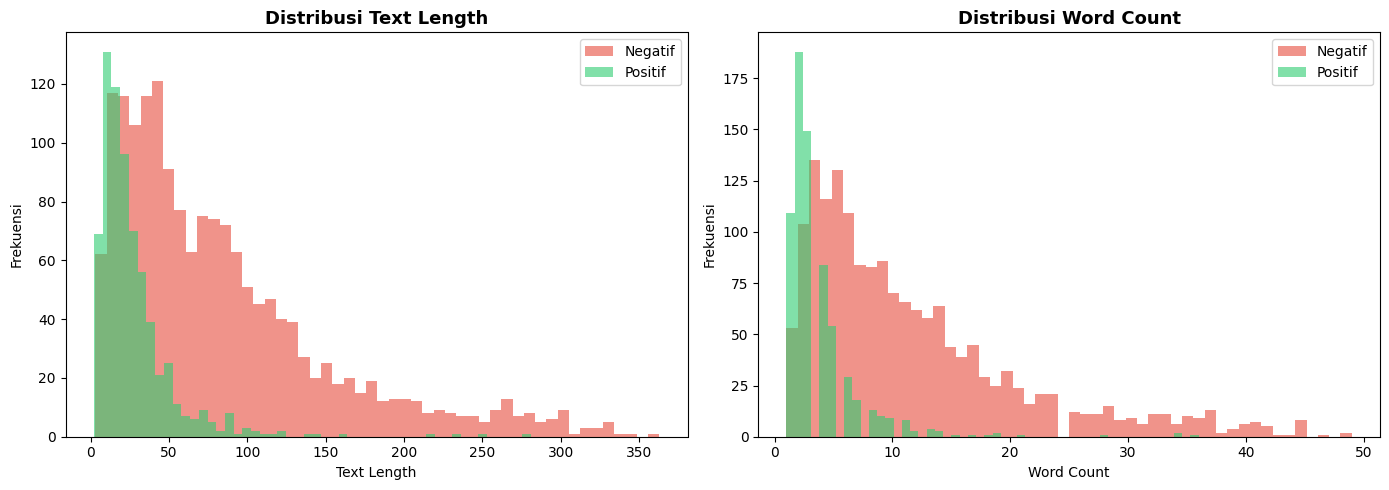

In [5]:
# Analisis panjang teks
df['text_length'] = df['content'].apply(len)
df['word_count'] = df['content'].apply(lambda x: len(x.split()))

print("📊 Statistik Panjang Teks:")
print(df.groupby('sentiment')[['text_length', 'word_count']].describe().round(1))

# Visualisasi panjang teks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['text_length', 'word_count']):
    for sent in df['sentiment'].unique():
        subset = df[df['sentiment'] == sent]
        label = 'Negatif' if sent == 'negative' else 'Positif'
        axes[i].hist(subset[col], bins=50, alpha=0.6, label=label,
                     color=colors.get(sent, '#3498db'))
    axes[i].set_title(f'Distribusi {col.replace("_", " ").title()}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend()

plt.tight_layout()
plt.show()

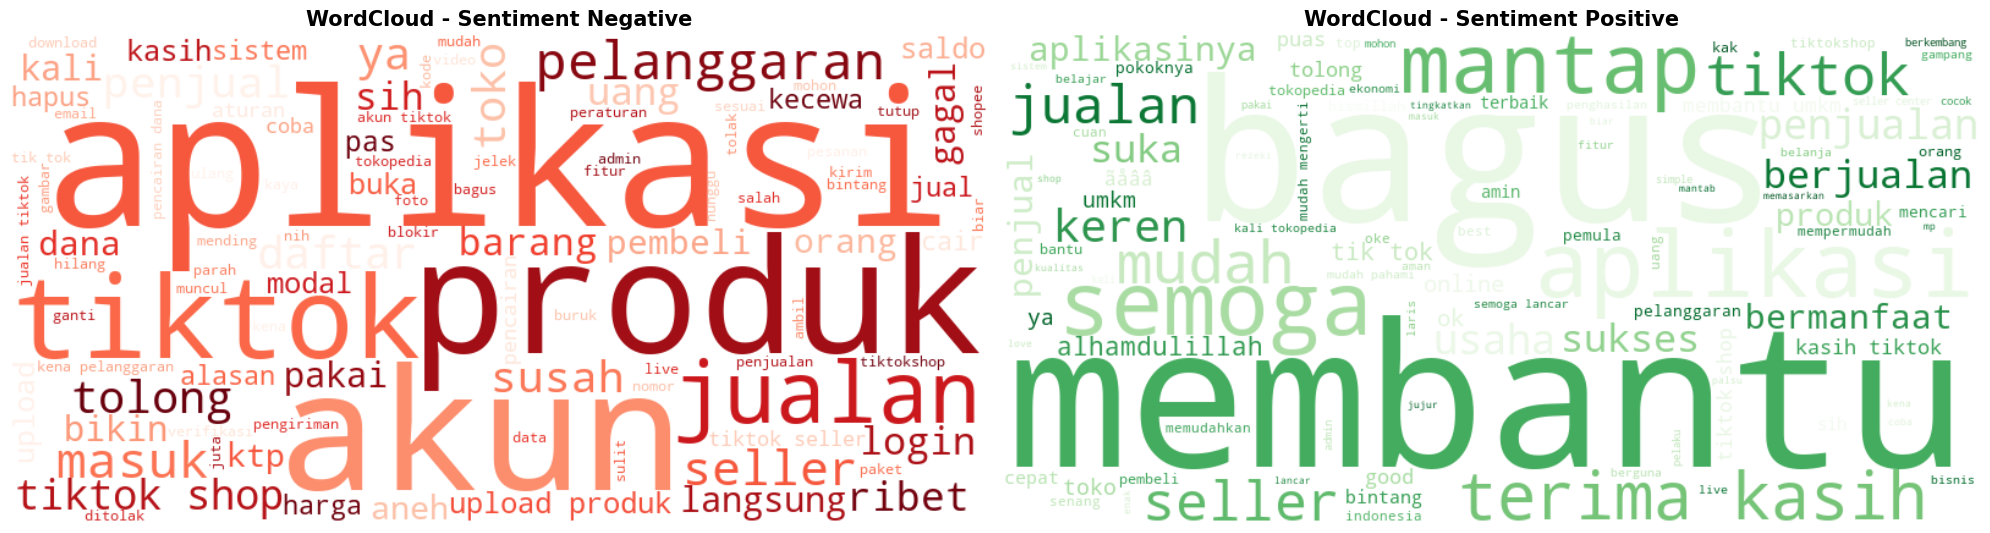

In [19]:
# WordCloud untuk masing-masing sentimen
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for i, sent in enumerate(['negative', 'positive']):
    text = ' '.join(df[df['sentiment'] == sent]['content'].astype(str))
    label = 'Negative' if sent == 'negative' else 'Positive'
    color = 'Reds' if sent == 'negative' else 'Greens'

    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=color, max_words=100).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'WordCloud - Sentiment {label}', fontsize=15, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

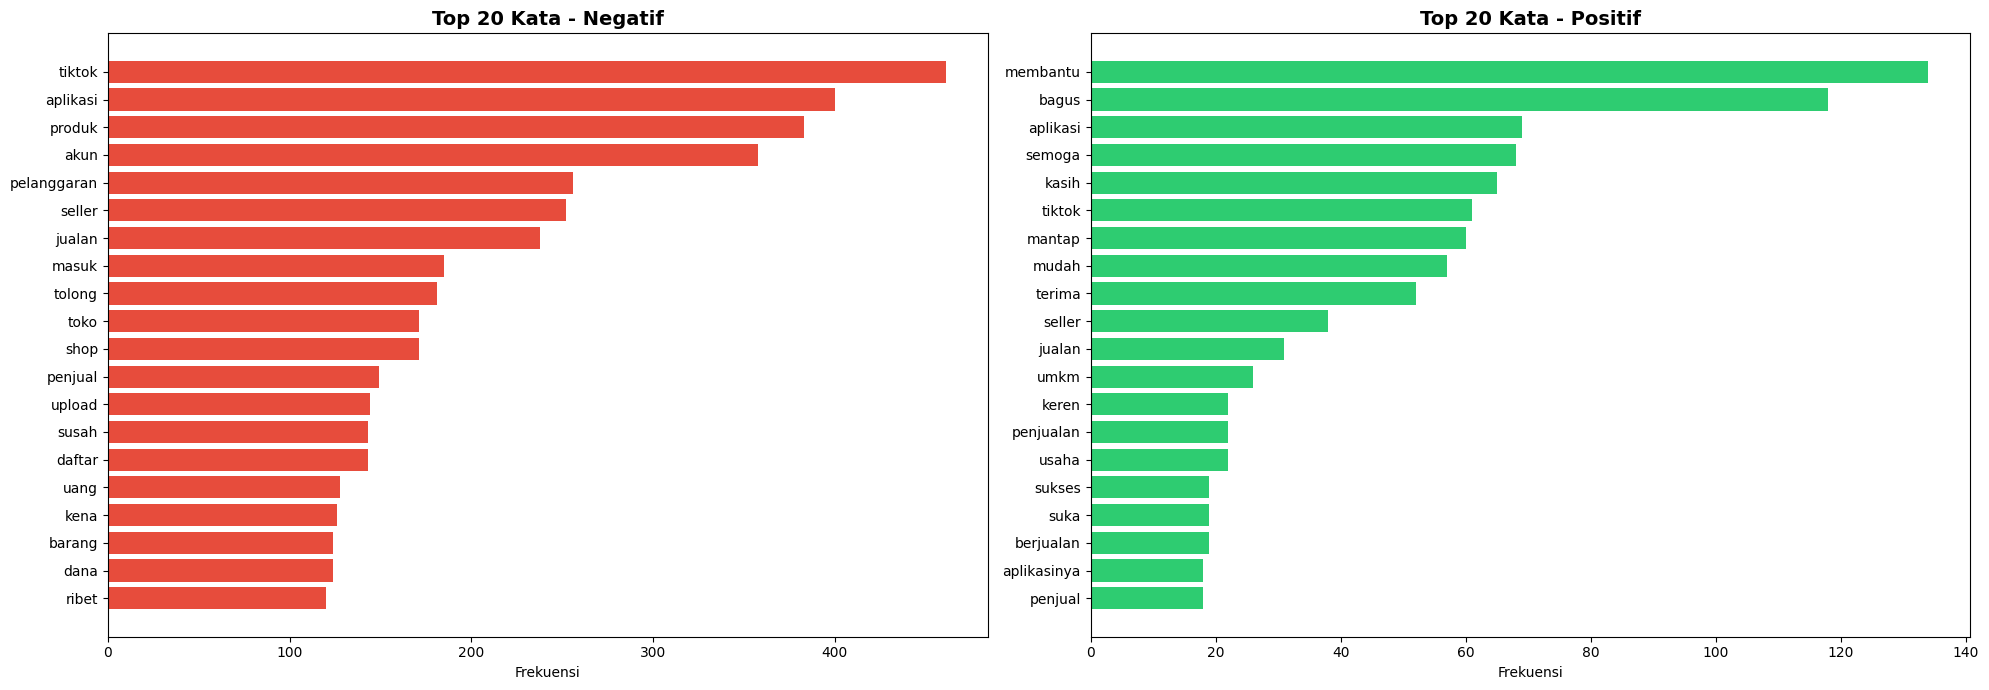

In [7]:
# Top 20 kata paling sering muncul
stop_words_id = set(stopwords.words('indonesian'))

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for i, sent in enumerate(['negative', 'positive']):
    text = ' '.join(df[df['sentiment'] == sent]['content'].astype(str))
    words = [w.lower() for w in text.split() if w.lower() not in stop_words_id
             and w.lower() not in string.punctuation and len(w) > 2]
    top_words = Counter(words).most_common(20)

    label = 'Negatif' if sent == 'negative' else 'Positif'
    color = '#e74c3c' if sent == 'negative' else '#2ecc71'

    ax = axes[i]
    ax.barh([w[0] for w in top_words[::-1]], [w[1] for w in top_words[::-1]], color=color)
    ax.set_title(f'Top 20 Kata - {label}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Frekuensi')

plt.tight_layout()
plt.show()

## 2. Preprocessing Teks

Tahap preprocessing meliputi:
- Case folding (lowercase)
- Menghapus URL, mention, hashtag
- Menghapus angka
- Menghapus tanda baca
- Menghapus karakter tidak valid
- Tokenisasi
- Menghapus stop words
- Stemming

In [8]:
# Stopword list hanya dari NLTK (Sastrawi di-skip karena butuh Java)
all_stopwords = set(stopwords.words('indonesian'))

# Daftar stopword tambahan (kata-kata umum domain tiktok seller)
extra_stopwords = {
    'yg', 'dg', 'dr', 'utk', 'sdh', 'udh', 'blm', 'klo', 'kalo', 'gk',
    'gak', 'ga', 'dong', 'sih', 'nih', 'kan', 'yah', 'ya', 'aja', 'doang',
    'deh', 'loh', 'lho', 'kok', 'mas', 'mbak', 'kak', 'bang', 'sis', 'min',
    'bro', 'gan', 'om', 'tante', 'admin', 'tiktok', 'shop', 'seller',
    'tokopedia', 'aplikasi', 'apk', 'app', 'online', 'jual', 'beli', 'produk',
    'barang', 'toko', 'pesan', 'order', 'jualan', 'pelanggan', 'pengguna',
    'saya', 'aku', 'kamu', 'dia', 'mereka', 'kita', 'kami', 'ini', 'itu',
    'yang', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan', 'pada', 'ada',
    'bisa', 'tidak', 'belum', 'bukan', 'juga', 'sudah', 'telah', 'akan',
    'mau', 'lagi', 'sedang', 'hanya', 'lebih', 'sangat', 'sekali', 'banget',
    'paling', 'setiap', 'jika', 'kalau', 'karena', 'jadi', 'maka', 'tapi',
    'namun', 'atau', 'baik', 'lain', 'serta', 'apakah', 'bagaimana',
    'kapan', 'dimana', 'siapa', 'mengapa', 'apa', 'hal', 'halnya', 'bagi',
    'bahkan', 'hampir', 'sekitar', 'dalam', 'antara', 'sambil', 'lalu',
    'kemudian', 'setelah', 'sebelum', 'selama', 'tentang', 'atas', 'bawah',
    'sini', 'situ', 'sana', 'begitu', 'seperti',
    'terus', 'lanjut', 'per', 'ribu', 'juta', 'tolong', 'mohon',
}
all_stopwords = all_stopwords.union(extra_stopwords)

print(f"✅ Total stopword: {len(all_stopwords)} kata")

✅ Total stopword: 815 kata


In [9]:
def preprocess_text(text):
    """Fungsi preprocessing teks lengkap"""
    if not isinstance(text, str):
        return ''

    # 1. Case folding
    text = text.lower()

    # 2. Hapus URL
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 3. Hapus mention & hashtag
    text = re.sub(r'@\w+|#\w+', '', text)

    # 4. Hapus angka
    text = re.sub(r'\d+', '', text)

    # 5. Hapus tanda baca & karakter khusus (ganti dengan spasi)
    text = re.sub(r'[^\w\s]', ' ', text)

    # 6. Hapus karakter tunggal/acak (emoji, karakter unicode aneh)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # 7. Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    # 8. Tokenisasi
    tokens = text.split()

    # 9. Hapus stopword (termasuk extra_stopwords)
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 2]

    return ' '.join(tokens)


print("🔧 Fungsi preprocessing siap digunakan!")

🔧 Fungsi preprocessing siap digunakan!


In [20]:
# Jalankan preprocessing
print("⏳ Proses preprocessing dimulai... (mungkin butuh beberapa menit)")
df['clean_text'] = df['content'].apply(preprocess_text)

# Hapus baris kosong setelah preprocessing
df = df[df['clean_text'].str.strip().astype(bool)].reset_index(drop=True)

print(f"✅ Preprocessing selesai! Jumlah data: {df.shape[0]}")
print(f"\n📋 Contoh hasil preprocessing (teks lengkap):")
for i in range(5):
    print(f"\n{'='*70}")
    print(f"Contoh {i+1}:")
    print(f"{'='*70}")
    print(f"📝 Original : {df['content'].iloc[i]}")
    print(f"🧹 Cleaned  : {df['clean_text'].iloc[i]}")
print(f"{'='*70}")

⏳ Proses preprocessing dimulai... (mungkin butuh beberapa menit)
✅ Preprocessing selesai! Jumlah data: 2364

📋 Contoh hasil preprocessing (teks lengkap):

Contoh 1:
📝 Original : tolong keuangan transfer rekening berbeda rekening daftarkan buka toko orang rekening ter isi rekening tolong pendaftaran toko batasi akun daftarkan hilang lupa sandi kasih minim kali
🧹 Cleaned  : keuangan transfer rekening berbeda rekening daftarkan buka orang rekening ter isi rekening pendaftaran batasi akun daftarkan hilang lupa sandi kasih minim kali

Contoh 2:
📝 Original : sumpah ya aplikasi seller buruk tuh duitnya langsung masuk saldo nunggu berhariãâ butuh modal belanja pakai kecewa aduh payah
🧹 Cleaned  : sumpah buruk tuh duitnya langsung masuk saldo nunggu berhari butuh modal belanja pakai kecewa aduh payah

Contoh 3:
📝 Original : susah ribet
🧹 Cleaned  : susah ribet

Contoh 4:
📝 Original : capai bikin dekripsi tolak kacau
🧹 Cleaned  : capai bikin dekripsi tolak kacau

Contoh 5:
📝 Original : pelanggar

## 3. Encoding Label & Splitting Data

In [11]:
# Encode label: negative=0, positive=1
df['label'] = df['sentiment'].map({'negative': 0, 'positive': 1})

print(f"📊 Distribusi label:")
print(f"  Negatif (0): {(df['label'] == 0).sum()}")
print(f"  Positif (1): {(df['label'] == 1).sum()}")

# Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"\n✅ Data berhasil di-split!")
print(f"  Training set: {X_train.shape[0]} data")
print(f"  Testing set : {X_test.shape[0]} data")

📊 Distribusi label:
  Negatif (0): 1681
  Positif (1): 683

✅ Data berhasil di-split!
  Training set: 1891 data
  Testing set : 473 data


## 4. Vectorization (TF-IDF)

In [12]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"✅ TF-IDF selesai!")
print(f"  Jumlah fitur (kata/biagram): {X_train_tfidf.shape[1]}")
print(f"  Training matrix: {X_train_tfidf.shape}")
print(f"  Testing matrix : {X_test_tfidf.shape}")

✅ TF-IDF selesai!
  Jumlah fitur (kata/biagram): 5000
  Training matrix: (1891, 5000)
  Testing matrix : (473, 5000)


## 5. Modelling (Naive Bayes, SVM, Random Forest)

In [13]:
# Definisi model
models = {
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(kernel='linear', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# Training & prediksi semua model
results = {}
predictions = {}

for name, model in models.items():
    print(f"\n🔧 Training {name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    y_prob = model.predict_proba(X_test_tfidf)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    predictions[name] = {'y_pred': y_pred, 'y_prob': y_prob}

    print(f"  ✅ {name} selesai! Accuracy: {acc:.4f}")

print("\n🎯 Semua model selesai ditraining!")


🔧 Training Naive Bayes...
  ✅ Naive Bayes selesai! Accuracy: 0.8922

🔧 Training SVM...
  ✅ SVM selesai! Accuracy: 0.9006

🔧 Training Random Forest...
  ✅ Random Forest selesai! Accuracy: 0.8964

🎯 Semua model selesai ditraining!


## 6. Evaluasi Model

📊 Perbandingan Hasil Model:
               Accuracy  Precision  Recall  F1-Score
Naive Bayes      0.8922     0.9479  0.6642    0.7811
SVM              0.9006     0.8750  0.7664    0.8171
Random Forest    0.8964     0.7651  0.9270    0.8383


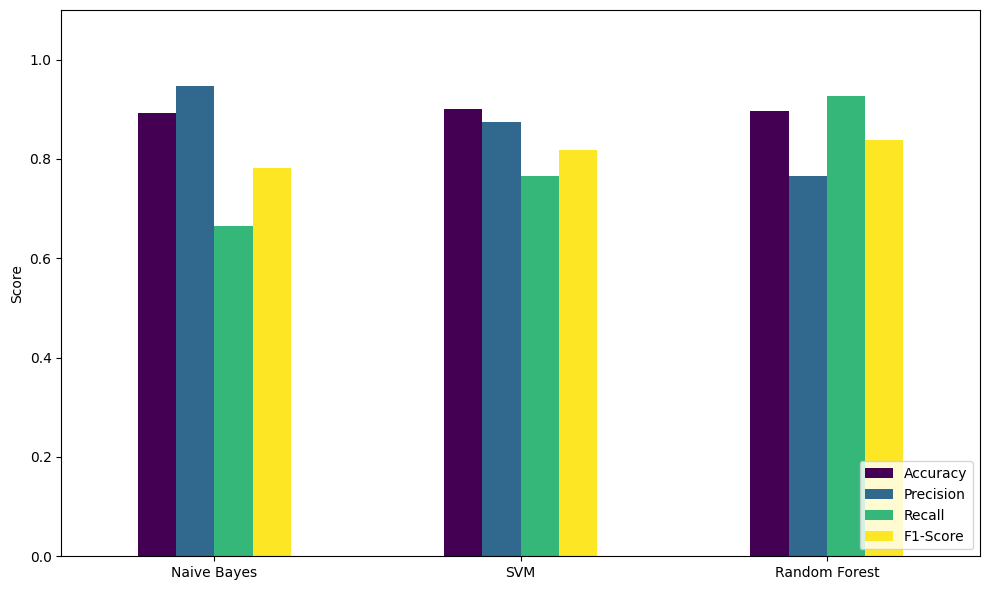

In [14]:
# Tabel perbandingan hasil semua model
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print("📊 Perbandingan Hasil Model:")
print("=" * 60)
print(results_df.to_string())
print("=" * 60)

# Visualisasi perbandingan metrik
fig, ax = plt.subplots(figsize=(10, 6))
results_df.plot(kind='bar', ax=ax, colormap='viridis')
#ax.set_title('Perbandingan Performa Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

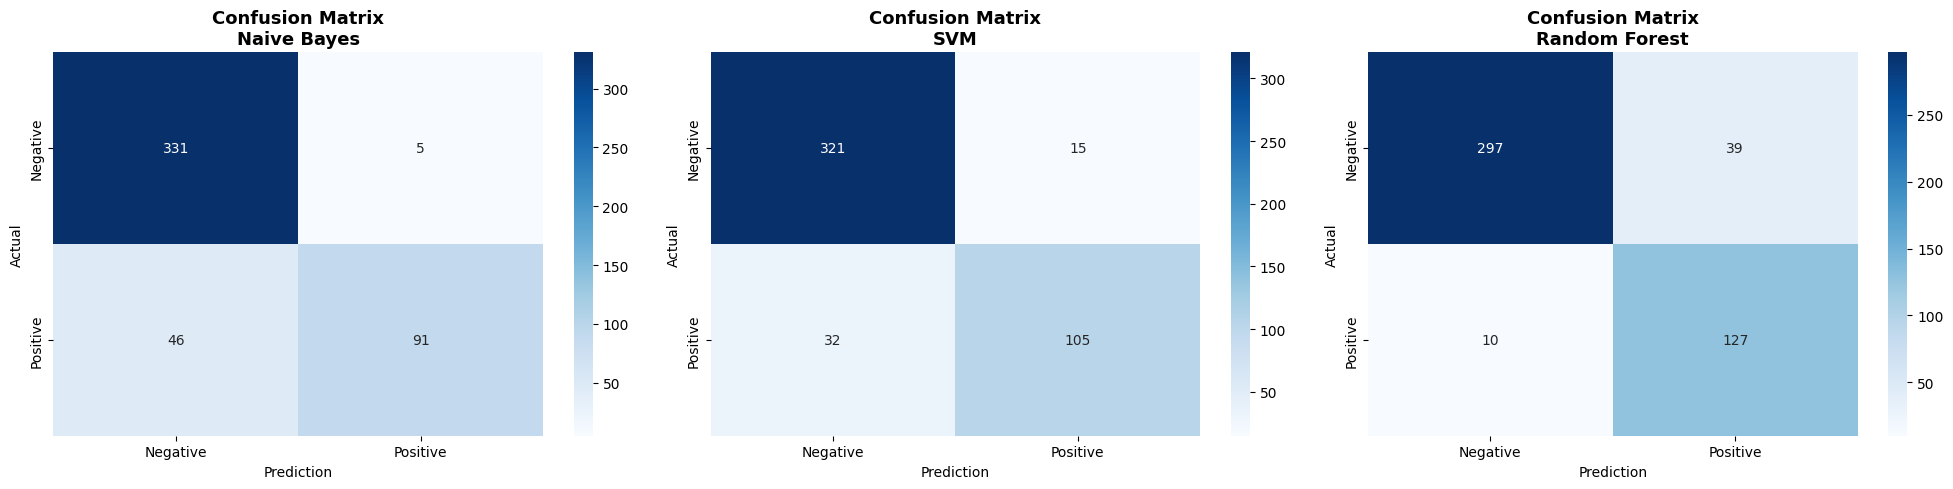

In [15]:
# Confusion Matrix untuk semua model
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, (name, _) in enumerate(models.items()):
    cm = confusion_matrix(y_test, predictions[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[i].set_title(f'Confusion Matrix\n{name}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Prediction')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [16]:
# Classification Report untuk semua model
for name in models.keys():
    print(f"\n{'='*60}")
    print(f"📋 Classification Report - {name}")
    print('='*60)
    print(classification_report(y_test, predictions[name]['y_pred'],
                                target_names=['Negatif', 'Positif']))


📋 Classification Report - Naive Bayes
              precision    recall  f1-score   support

     Negatif       0.88      0.99      0.93       336
     Positif       0.95      0.66      0.78       137

    accuracy                           0.89       473
   macro avg       0.91      0.82      0.85       473
weighted avg       0.90      0.89      0.89       473


📋 Classification Report - SVM
              precision    recall  f1-score   support

     Negatif       0.91      0.96      0.93       336
     Positif       0.88      0.77      0.82       137

    accuracy                           0.90       473
   macro avg       0.89      0.86      0.87       473
weighted avg       0.90      0.90      0.90       473


📋 Classification Report - Random Forest
              precision    recall  f1-score   support

     Negatif       0.97      0.88      0.92       336
     Positif       0.77      0.93      0.84       137

    accuracy                           0.90       473
   macro avg     

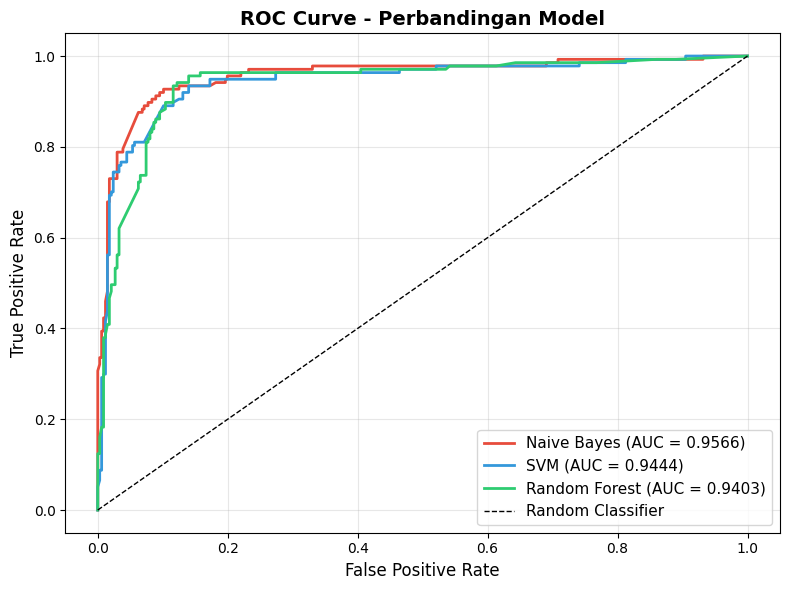

In [17]:
# ROC Curve untuk semua model
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#e74c3c', '#3498db', '#2ecc71']

for i, (name, _) in enumerate(models.items()):
    fpr, tpr, _ = roc_curve(y_test, predictions[name]['y_prob'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors_roc[i], linewidth=2,
            label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Perbandingan Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 📌 Kesimpulan

Berdasarkan hasil analisis sentimen terhadap ulasan TikTok Seller Center:

1. **EDA**: Data terdiri dari ulasan berbahasa Indonesia dengan distribusi sentimen negatif dan positif. Mayoritas ulasan bernada negatif.

2. **Preprocessing**: Teks telah melalui tahap case folding, penghapusan URL/angka/tanda baca, stopword removal, dan stemming menggunakan Sastrawi.

3. **Vectorization**: Menggunakan TF-IDF dengan unigram dan bigram (5000 fitur maksimal).

4. **Modelling**: Tiga model telah ditraining — Naive Bayes, SVM, dan Random Forest.

5. **Evaluasi**: Model dibandingkan berdasarkan Accuracy, Precision, Recall, F1-Score, Confusion Matrix, dan ROC Curve.

In [18]:
# Model terbaik
best_model_name = results_df['Accuracy'].idxmax()
best_acc = results_df.loc[best_model_name, 'Accuracy']
print(f"🏆 Model terbaik: {best_model_name} dengan Accuracy: {best_acc:.4f}")

# Demo prediksi dengan teks baru
print("\n" + "="*60)
print("🧪 DEMO PREDIKSI")
print("="*60)

test_texts = [
    "aplikasi bagus membantu penjualan laris",
    "parah aplikasi pelanggaran terus uang tidak cair",
    "ribet susah upload produk gagal terus",
    "mantap mudah digunakan penjualan meningkat",
    "pencairan dana lama merugikan penjual"
]

best_model = models[best_model_name]
for text in test_texts:
    clean = preprocess_text(text)
    vec = tfidf.transform([clean])
    pred = best_model.predict(vec)[0]
    label = "Positif ✅" if pred == 1 else "Negatif ❌"
    print(f"  \"{text}\"")
    print(f"  → Prediksi: {label}\n")

🏆 Model terbaik: SVM dengan Accuracy: 0.9006

🧪 DEMO PREDIKSI
  "aplikasi bagus membantu penjualan laris"
  → Prediksi: Positif ✅

  "parah aplikasi pelanggaran terus uang tidak cair"
  → Prediksi: Negatif ❌

  "ribet susah upload produk gagal terus"
  → Prediksi: Negatif ❌

  "mantap mudah digunakan penjualan meningkat"
  → Prediksi: Positif ✅

  "pencairan dana lama merugikan penjual"
  → Prediksi: Negatif ❌

